In [1]:
import matplotlib.pyplot as plt 
import numpy as np 
import os 
import pandas as pd # 

In [2]:
df = pd.read_csv('match_data_300_tourns_modified.csv')
df.head()

,player1,player2,best_of,player1_elo,player2_elo,elo_match_win_rate,elo_frame_win_rate,p1_matches_played,p1_matches_won,p1_frames_played,...,p2_frames_played_1_year,p2_frames_won_1_year,p2_frames_played_3_years,p2_frames_won_3_years,score1,score2,match_result,win_percentage,tournament_id,date
0,Mark Allen,Ricky Walden,7,1580,1418,0.709992,0.599888,501,313,3345,...,45,25,1032,557,0,4,1.0,0.000000,1063,1.415318e+18
1,Stephen Maguire,Judd Trump,7,1563,1551,0.516401,0.507499,663,444,4995,...,122,79,1344,782,1,4,1.0,0.200000,1063,1.415059e+18
2,Mark Selby,Steve Davis,7,1592,1246,0.878716,0.703704,736,495,5330,...,8,2,581,286,4,1,0.0,0.800000,1063,1.415059e+18
3,Neil Robertson,Ali Carter,7,1546,1544,0.502734,0.501250,621,402,4581,...,11,5,876,499,4,0,0.0,1.000000,1063,1.415318e+18
4,Stuart Bingham,Ronnie O'Sullivan,7,1488,1663,0.275106,0.392337,744,462,5592,...,71,46,674,431,2,4,1.0,0.333333,1063,1.415146e+18


In [3]:
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df, 
                                        test_size = 0.2,
                                        shuffle=False)

### XG Boost with statistical features


In [4]:
features_to_remove = ['player1', 'player2', 'player1_elo','player2_elo','elo_match_win_rate','elo_frame_win_rate',
                      'score1','score2','match_result','win_percentage','tournament_id']
X = df_train.drop(columns=features_to_remove) 
y = df_train['win_percentage']

In [5]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
from sklearn.metrics import make_scorer, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
import numpy as np

In [7]:
kf = KFold(n_splits=5)

model = XGBRegressor(objective='reg:squarederror', random_state=20, verbosity=0)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

rmse_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=kf,
    scoring=rmse_scorer,
    verbose=2
)

grid_search.fit(X, y)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.3s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.1s
[CV] END c

GridSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=False),
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    i...
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=20, ...),
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200], 'subsample': [0.8, 1.0]},
             scoring=make_scorer(mean_absolute_error, greater_is_better=False, response_method='predict'),
             verbose=2)

In [8]:
best_cv_score = grid_search.best_score_
print("Average CV score of best parameters:", -best_cv_score)

best_params = grid_search.best_params_
print("Best parameters:", best_params)

Average CV score of best parameters: 0.214222305996562
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}


### XG Boost with statistical features based on player statistic differences

In [9]:
dfm = df_train.copy()
dfm['p1_matches_win_ratio']=dfm['p1_matches_won']/df['p1_matches_played']
dfm['p2_matches_win_ratio']=dfm['p2_matches_won']/df['p2_matches_played']
dfm['p1_frames_win_ratio']=dfm['p1_frames_won']/df['p1_frames_played']
dfm['p2_frames_win_ratio']=dfm['p2_frames_won']/df['p2_frames_played']
dfm['p1_frames_win_ratio_1_year']=dfm['p1_frames_won_1_year']/df['p1_frames_played_1_year']
dfm['p2_frames_win_ratio_1_year']=dfm['p2_frames_won_1_year']/df['p2_frames_played_1_year']
dfm['p1_frames_win_ratio_3_years']=dfm['p1_frames_won_3_years']/df['p1_frames_played_3_years']
dfm['p2_frames_win_ratio_3_years']=dfm['p2_frames_won_3_years']/df['p2_frames_played_3_years']
dfm.fillna(0.5, inplace=True)
dfm['matches_win_ratio_diff']=dfm['p1_matches_win_ratio']-dfm['p2_matches_win_ratio']
dfm['frames_win_ratio_diff']=dfm['p1_frames_win_ratio']-dfm['p2_frames_win_ratio']
dfm['frames_win_ratio_diff_1_year']=dfm['p1_frames_win_ratio_1_year']-dfm['p2_frames_win_ratio_1_year']
dfm['frames_win_ratio_diff_3_years']=dfm['p1_frames_win_ratio_3_years']-dfm['p2_frames_win_ratio_3_years']

In [10]:
selected_features = ['matches_win_ratio_diff','frames_win_ratio_diff','frames_win_ratio_diff_1_year','frames_win_ratio_diff_3_years']
X = dfm[selected_features]
y = dfm['win_percentage']

In [11]:
kf = KFold(n_splits=5)

model = XGBRegressor(objective='reg:squarederror', random_state=20, verbosity=0)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

rmse_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=kf,
    scoring=rmse_scorer,
    verbose=2
)

grid_search.fit(X, y)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.1s
[CV] END c

GridSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=False),
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    i...
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=20, ...),
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200], 'subsample': [0.8, 1.0]},
             scoring=make_scorer(mean_absolute_error, greater_is_better=False, response_method='predict'),
             verbose=2)

In [12]:
best_cv_score = grid_search.best_score_
print("Average CV score of best parameters:", -best_cv_score)

best_params = grid_search.best_params_
print("Best parameters:", best_params)

Average CV score of best parameters: 0.2256889031282315
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


In [14]:
final_model = XGBRegressor(**best_params, objective='reg:squarederror', random_state=20)
final_model.fit(X, y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=20, ...)

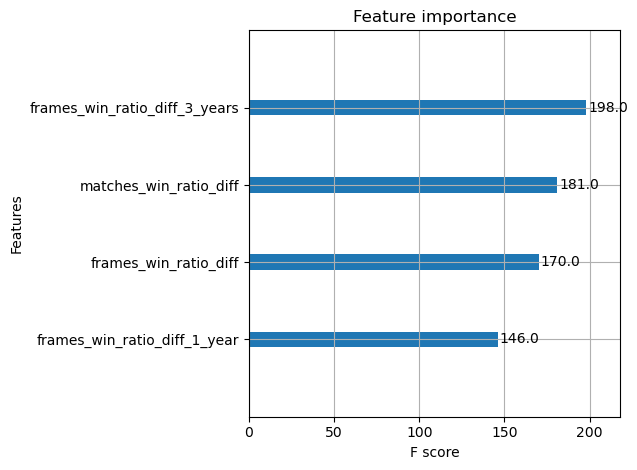

In [15]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(final_model, importance_type='weight')  
plt.tight_layout()
plt.show()

### XG Boost on all available features

In [16]:
features_to_remove = ['player1', 'player2', 
                      'score1','score2','match_result','win_percentage','tournament_id']
X = df_train.drop(columns=features_to_remove) 
y = df_train['win_percentage']

In [17]:
kf = KFold(n_splits=5)

model = XGBRegressor(objective='reg:squarederror', random_state=20, verbosity=0)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

rmse_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=kf,
    scoring=rmse_scorer,
    verbose=2
)

grid_search.fit(X, y)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.1s
[CV] END c

GridSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=False),
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    i...
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=20, ...),
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200], 'subsample': [0.8, 1.0]},
             scoring=make_scorer(mean_absolute_error, greater_is_better=False, response_method='predict'),
             verbose=2)

In [18]:
best_cv_score = grid_search.best_score_
print("Average CV score of best parameters:", -best_cv_score)

best_params = grid_search.best_params_
print("Best parameters:", best_params)

Average CV score of best parameters: 0.20921168821218822
Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


Average CV MAE with feature set 1: 0.2142

Average CV MAE with feature set 2: 0.2257

Average CV MAE with feature set 3: 0.2092